# ICFR / SOx Control Testing — Analysis in Python

**Author:** Sadia Saad Yusuf, CA

An internal-controls-over-financial-reporting (ICFR) testing programme, analysed
entirely in Python. Starting from a **Risk Control Matrix** of 35 controls with
test results, this notebook measures control health and produces a management view:

- Overall pass rate and deficiency count (KPIs)
- Pass rate by process — where the control environment is weakest
- Deficiency severity, and **design vs operating** effectiveness split
- **Manual vs automated** control performance
- Remediation status and **overdue / aging** analysis
- A prioritised remediation worklist for stakeholders

*Data: `icfr_control_testing_data.csv` — a fixed, ready-to-use dataset.
Analysis "as of" date: 30 Sep 2025.*

## 1. Load the Risk Control Matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

NAVY, ACCENT = "#1F3864", "#2E5090"
C_PASS, C_EXC, C_FAIL = "#4CAF7D", "#E8B84B", "#D9534F"
REPORT_DATE = pd.Timestamp("2025-09-30")   # analysis as-of date

df = pd.read_csv("icfr_control_testing_data.csv",
                 parse_dates=["Test_Date", "Remediation_Due_Date"])
print(f"{len(df)} controls across {df['Process'].nunique()} processes")
df.head()

35 controls across 6 processes


,Control_ID,Process,Risk_ID,Risk_Description,Control_Description,Control_Owner,Control_Type,Control_Nature,Frequency,Assertion,...,Sample_Size,Exceptions_Noted,Test_Date,Tester,Test_Result,Deficiency_Type,Deficiency_Severity,Remediation_Owner,Remediation_Due_Date,Remediation_Status
0,C-101,Procure-to-Pay,R-101,Purchase orders approved by an authorised appr...,Purchase orders approved by an authorised appr...,R. Kapoor,Preventive,Manual,Per transaction,Occurrence,...,25,0,2025-08-01,Reviewer B,Pass,NaN,NaN,NaN,NaT,NaN
1,C-102,Procure-to-Pay,R-102,"Three-way match (PO, GRN, invoice) performed b...","Three-way match (PO, GRN, invoice) performed b...",S. Iyer,Preventive,Automated,Daily,Accuracy,...,25,0,2025-08-24,Sadia Y.,Pass,NaN,NaN,NaN,NaT,NaN
2,C-103,Procure-to-Pay,R-103,Vendor master additions/changes independently ...,Vendor master additions/changes independently ...,S. Iyer,Detective,Manual,Quarterly,Validity,...,2,1,2025-04-08,Sadia Y.,Fail,Design,High,A. Mehta,2025-05-08,Open
3,C-104,Procure-to-Pay,R-104,Duplicate-invoice system check runs before pay...,Duplicate-invoice system check runs before pay...,K. Malhotra,Preventive,Automated,Daily,Occurrence,...,25,0,2025-07-11,Reviewer A,Pass,NaN,NaN,NaN,NaT,NaN
4,C-105,Procure-to-Pay,R-105,Payments above threshold require dual authoris...,Payments above threshold require dual authoris...,S. Iyer,Preventive,Manual,Per transaction,Occurrence,...,25,0,2025-08-18,Sadia Y.,Pass,NaN,NaN,NaN,NaT,NaN


## 2. Profile the data

In [2]:
print("Shape:", df.shape)
print("\nControls per process:")
print(df["Process"].value_counts().to_string())
print("\nColumns:", list(df.columns))

Shape: (35, 22)

Controls per process:
Process
Procure-to-Pay     7
Order-to-Cash      6
Financial Close    6
ITGC               6
Payroll            5
Treasury           5

Columns: ['Control_ID', 'Process', 'Risk_ID', 'Risk_Description', 'Control_Description', 'Control_Owner', 'Control_Type', 'Control_Nature', 'Frequency', 'Assertion', 'Test_Procedure', 'Population_Size', 'Sample_Size', 'Exceptions_Noted', 'Test_Date', 'Tester', 'Test_Result', 'Deficiency_Type', 'Deficiency_Severity', 'Remediation_Owner', 'Remediation_Due_Date', 'Remediation_Status']


## 3. Derive the metrics we'll test on

- **Exception_Rate** = exceptions noted ÷ sample size
- **Is_Deficient** = the control did not pass
- **Days_Overdue** = how far past its remediation due date an *open* deficiency is, as of the report date

In [3]:
df["Exception_Rate"] = df["Exceptions_Noted"] / df["Sample_Size"]
df["Is_Deficient"] = df["Test_Result"].isin(["Exception", "Fail"])

open_mask = df["Remediation_Status"].isin(["Open", "In Progress"])
df["Days_Overdue"] = np.where(
    open_mask & df["Remediation_Due_Date"].notna(),
    (REPORT_DATE - df["Remediation_Due_Date"]).dt.days, np.nan)
df["Is_Overdue"] = df["Days_Overdue"] > 0

df[["Control_ID","Process","Test_Result","Exceptions_Noted","Sample_Size",
    "Exception_Rate","Deficiency_Severity","Days_Overdue"]].head()

,Control_ID,Process,Test_Result,Exceptions_Noted,Sample_Size,Exception_Rate,Deficiency_Severity,Days_Overdue
0,C-101,Procure-to-Pay,Pass,0,25,0.0,NaN,NaN
1,C-102,Procure-to-Pay,Pass,0,25,0.0,NaN,NaN
2,C-103,Procure-to-Pay,Fail,1,2,0.5,High,145.0
3,C-104,Procure-to-Pay,Pass,0,25,0.0,NaN,NaN
4,C-105,Procure-to-Pay,Pass,0,25,0.0,NaN,NaN


## 4. Headline KPIs

In [4]:
total = len(df)
passed = (df["Test_Result"] == "Pass").sum()
pass_rate = passed / total
deficiencies = int(df["Is_Deficient"].sum())
high_sev = (df["Deficiency_Severity"] == "High").sum()
open_defs = (df["Is_Deficient"] & open_mask).sum()
overdue = int(df["Is_Overdue"].sum())

print("="*46)
print("  ICFR CONTROL TESTING — SUMMARY (as of 30 Sep 2025)")
print("="*46)
print(f"  Controls tested        : {total}")
print(f"  Pass rate              : {pass_rate:.1%}  ({passed}/{total})")
print(f"  Deficiencies           : {deficiencies}")
print(f"    - High severity      : {high_sev}")
print(f"  Open deficiencies      : {open_defs}")
print(f"  Overdue remediations   : {overdue}")
print("="*46)

  ICFR CONTROL TESTING — SUMMARY (as of 30 Sep 2025)
  Controls tested        : 35
  Pass rate              : 80.0%  (28/35)
  Deficiencies           : 7
    - High severity      : 3
  Open deficiencies      : 6
  Overdue remediations   : 4


## 5. Test-result distribution

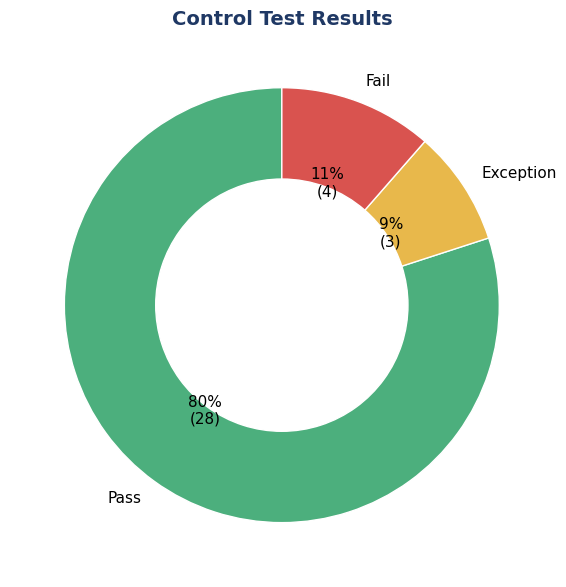

In [5]:
counts = df["Test_Result"].value_counts().reindex(["Pass","Exception","Fail"]).fillna(0)
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(counts, labels=counts.index, autopct=lambda p: f"{p:.0f}%\n({int(round(p*total/100))})",
       colors=[C_PASS, C_EXC, C_FAIL], startangle=90,
       wedgeprops=dict(width=0.42, edgecolor="white"))
ax.set_title("Control Test Results", fontsize=14, color=NAVY, weight="bold")
plt.tight_layout(); plt.show()

## 6. Pass rate by process

This is the money chart for a controls team: it shows **where the control
environment is weakest** and where to direct assurance effort.

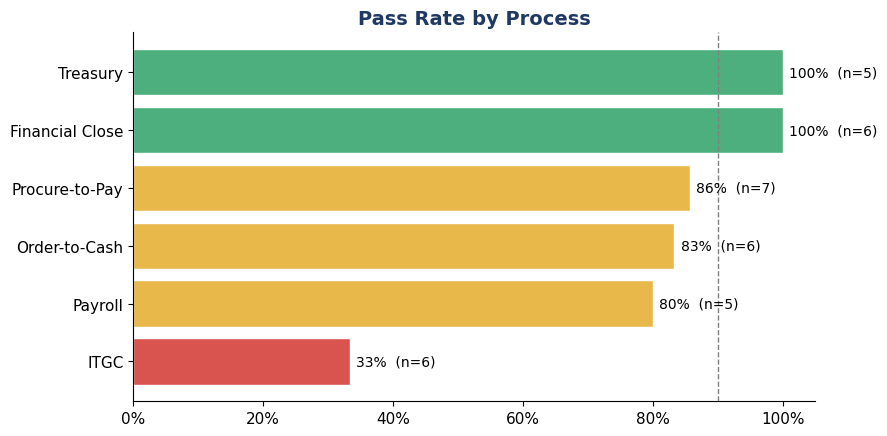

,controls,pass_rate
Process,,
ITGC,6,33.3
Payroll,5,80.0
Order-to-Cash,6,83.3
Procure-to-Pay,7,85.7
Financial Close,6,100.0
Treasury,5,100.0


In [6]:
by_proc = (df.assign(passed=df["Test_Result"].eq("Pass"))
             .groupby("Process")
             .agg(controls=("Control_ID","size"), pass_rate=("passed","mean"))
             .sort_values("pass_rate"))

fig, ax = plt.subplots(figsize=(9,4.5))
colors = [C_FAIL if r < 0.8 else C_EXC if r < 0.95 else C_PASS for r in by_proc["pass_rate"]]
bars = ax.barh(by_proc.index, by_proc["pass_rate"], color=colors, edgecolor="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, 1.05)
for b, (r, n) in zip(bars, zip(by_proc["pass_rate"], by_proc["controls"])):
    ax.text(r+0.01, b.get_y()+b.get_height()/2, f"{r:.0%}  (n={n})", va="center", fontsize=10)
ax.set_title("Pass Rate by Process", fontsize=14, color=NAVY, weight="bold")
ax.axvline(0.9, ls="--", color="grey", lw=1)
plt.tight_layout(); plt.show()
by_proc.assign(pass_rate=lambda d: (d.pass_rate*100).round(1))

## 7. Deficiency severity and design-vs-operating split

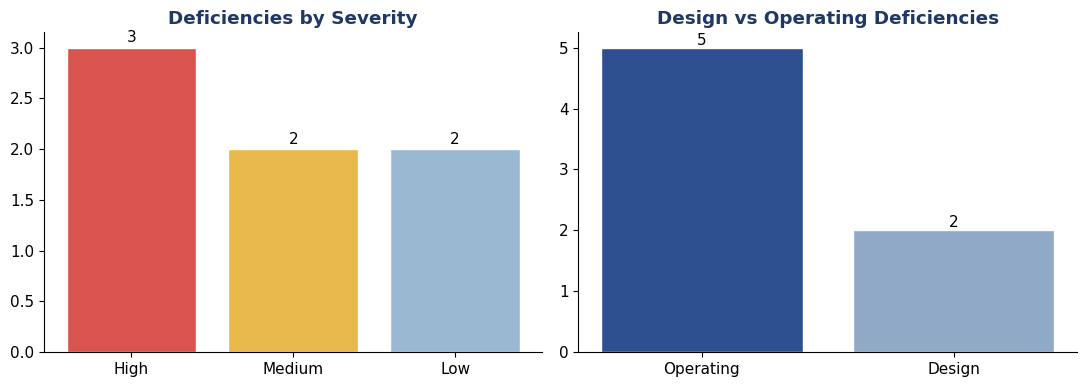

Design deficiencies are more serious — the control isn't capable of working,
not just failing in operation. Count by type:
Deficiency_Type
Operating    5
Design       2


In [7]:
defs = df[df["Is_Deficient"]]
sev = defs["Deficiency_Severity"].value_counts().reindex(["High","Medium","Low"]).fillna(0)
dtype = defs["Deficiency_Type"].value_counts()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4))
a1.bar(sev.index, sev.values, color=[C_FAIL, C_EXC, "#9BB8D3"], edgecolor="white")
a1.set_title("Deficiencies by Severity", color=NAVY, weight="bold")
for i,v in enumerate(sev.values): a1.text(i, v+0.05, int(v), ha="center")

a2.bar(dtype.index, dtype.values, color=[ACCENT, "#8FA9C7"], edgecolor="white")
a2.set_title("Design vs Operating Deficiencies", color=NAVY, weight="bold")
for i,v in enumerate(dtype.values): a2.text(i, v+0.05, int(v), ha="center")
plt.tight_layout(); plt.show()

print("Design deficiencies are more serious — the control isn't capable of working,")
print("not just failing in operation. Count by type:")
print(dtype.to_string())

## 8. Manual vs automated control performance

A classic assurance insight: automated controls should outperform manual ones.
Quantifying it tells management **where automation would reduce risk**.

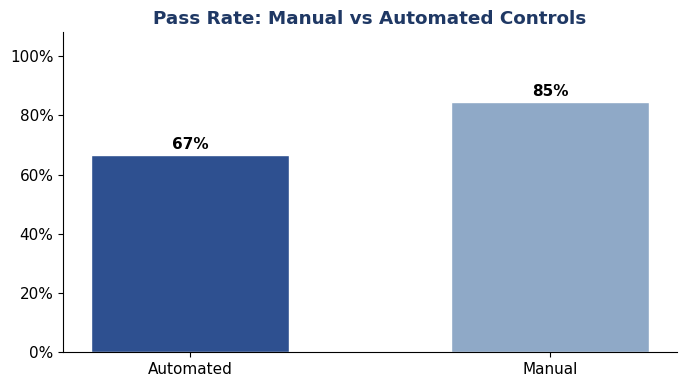

,controls,pass_rate,avg_exc_rate
Control_Nature,,,
Automated,9,66.7,6.8
Manual,26,84.6,12.2


In [8]:
nat = (df.assign(passed=df["Test_Result"].eq("Pass"))
         .groupby("Control_Nature")
         .agg(controls=("Control_ID","size"),
              pass_rate=("passed","mean"),
              avg_exc_rate=("Exception_Rate","mean")))

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(nat.index, nat["pass_rate"], color=[ACCENT, "#8FA9C7"], edgecolor="white", width=0.55)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0,1.08)
for b, r in zip(bars, nat["pass_rate"]):
    ax.text(b.get_x()+b.get_width()/2, r+0.02, f"{r:.0%}", ha="center", fontsize=11, weight="bold")
ax.set_title("Pass Rate: Manual vs Automated Controls", color=NAVY, weight="bold")
plt.tight_layout(); plt.show()
nat.assign(pass_rate=lambda d:(d.pass_rate*100).round(1),
           avg_exc_rate=lambda d:(d.avg_exc_rate*100).round(1))

## 9. Remediation aging — what's overdue

Open deficiencies past their due date are the assurance team's escalation list.

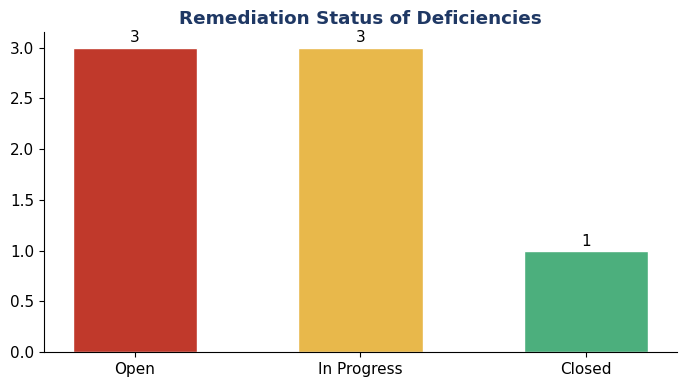

4 remediation(s) overdue as of 2025-09-30:



,Control_ID,Process,Deficiency_Severity,Remediation_Owner,Remediation_Due_Date,Days_Overdue,Remediation_Status
2,C-103,Procure-to-Pay,High,A. Mehta,2025-05-08,145.0,Open
11,C-112,Order-to-Cash,Medium,T. George,2025-06-07,115.0,In Progress
28,C-129,ITGC,High,N. Verma,2025-06-08,114.0,In Progress
14,C-115,Payroll,Medium,S. Iyer,2025-07-09,83.0,Open


In [9]:
overdue_df = (df[df["Is_Overdue"]]
    [["Control_ID","Process","Deficiency_Severity","Remediation_Owner",
      "Remediation_Due_Date","Days_Overdue","Remediation_Status"]]
    .sort_values("Days_Overdue", ascending=False))

status = df.loc[df["Is_Deficient"], "Remediation_Status"].value_counts()
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(status.index, status.values, color=["#C0392B","#E8B84B","#4CAF7D"][:len(status)],
       edgecolor="white", width=0.55)
for i,v in enumerate(status.values): ax.text(i, v+0.05, int(v), ha="center")
ax.set_title("Remediation Status of Deficiencies", color=NAVY, weight="bold")
plt.tight_layout(); plt.show()

print(f"{len(overdue_df)} remediation(s) overdue as of {REPORT_DATE.date()}:\n")
overdue_df

## 10. Prioritised remediation worklist (for management reporting)

In [10]:
worklist = (df[df["Is_Deficient"] & open_mask]
    .assign(Days_Overdue=lambda d: d["Days_Overdue"].fillna(0).astype(int))
    .sort_values(["Deficiency_Severity","Days_Overdue"],
                 key=lambda s: s.map({"High":0,"Medium":1,"Low":2}) if s.name=="Deficiency_Severity" else s,
                 ascending=[True, False])
    [["Control_ID","Process","Control_Description","Deficiency_Type",
      "Deficiency_Severity","Remediation_Owner","Remediation_Due_Date",
      "Days_Overdue","Remediation_Status"]]
    .reset_index(drop=True))
worklist

,Control_ID,Process,Control_Description,Deficiency_Type,Deficiency_Severity,Remediation_Owner,Remediation_Due_Date,Days_Overdue,Remediation_Status
0,C-103,Procure-to-Pay,Vendor master additions/changes independently ...,Design,High,A. Mehta,2025-05-08,145,Open
1,C-129,ITGC,Terminated users' access revoked within SLA,Operating,High,N. Verma,2025-06-08,114,In Progress
2,C-130,ITGC,Backup jobs monitored and failures investigated,Design,High,P. Nair,2025-11-11,-42,Open
3,C-112,Order-to-Cash,Credit notes approved by an authorised manager,Operating,Medium,T. George,2025-06-07,115,In Progress
4,C-115,Payroll,Payroll register reviewed and approved before ...,Operating,Medium,S. Iyer,2025-07-09,83,Open
5,C-127,ITGC,Change-management approvals obtained before de...,Operating,Low,D. Menon,2025-11-19,-50,In Progress


## Findings & how this maps to a controls-assurance role

**What the analysis shows (illustrative, on this dataset):**
- Overall pass rate with a small number of deficiencies, concentrated in the weaker
  processes — exactly the risk-based picture an assurance lead needs.
- Automated controls outperform manual ones, pointing to where automation lowers risk.
- A handful of open remediations are overdue and need escalation.

**Why this is the controls-assurance skillset, in code:**
- **Design & operating-effectiveness testing** — results captured per control, split by deficiency type.
- **Risk-based prioritisation** — severity + overdue days drive the worklist.
- **Coverage & consistency** — the same test logic runs across every control and process.
- **Stakeholder reporting** — KPIs, charts, and a ready worklist for senior management.

*The full population of results and the underlying matrix can equally be delivered
as an Excel + Power BI pack; this notebook shows the analysis performed directly in Python.*